In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import crosscoders as xc
import torch
import numpy as np

import matplotlib.pyplot as plt
import pandas as pd


------------------------- CONSTANTS -------------------------
GlobalsConfig(
    PROJECT_ROOT_DIR = '/home/ec2-user/crosscoders',
    CONFIG_FILEPATH = '/home/ec2-user/crosscoders/src/scripts/configs/train.yml',
    EXPERIMENT = ExperimentConfig(
        BATCH_SIZE = 8192,
        MAX_RECORDS = None,
        MAX_BATCHES = 1000000,
        MAX_TOKENS = 100000,
        NUM_GPUS = 1,
        NUM_TRAINERS = 1,
        HARDWARE = HardwareConfig(
            dtype = torch.float32,
            device = 'cuda',
        ),
    ),
)
-------------------------------------------------------------



In [3]:
import ray, ray.tune
from ray import tune
from ray.tune.schedulers import ASHAScheduler

from hyperopt import hp
from ray.tune.search.hyperopt import HyperOptSearch

In [4]:
from src.scripts.train import train_loop_per_worker

In [ ]:
from ray.tune.progress_reporter import CLIReporter, JupyterNotebookReporter

In [5]:
from crosscoders.constants import CONSTANTS
from crosscoders.dataclasses.configs.runner import RunnerConfig
from crosscoders.utils import from_dict, get_config


cfg = from_dict(
    RunnerConfig,
    get_config(CONSTANTS.CONFIG_FILEPATH).get('RUNNER', {})
)
cfg

RunnerConfig(
    MODEL = ModelConfig(
        CAUSALITY = 'acausal',
        LOCALITY = 'global',
        N_LAYERS = 12,
        D_MODEL = 768,
        D_CODER = 16384,
        HARDWARE = HardwareConfig(
            dtype = torch.float32,
            device = 'cuda',
        ),
    ),
    LOSS = AcausalLossConfig(
        L1_COEFFICIENT = 1.0,
    ),
    OPTIMIZER = OptimizerConfig(
        optimizer = <class 'torch.optim.adam.Adam'>,
        parameters = OptimizerParameters(
            lr = 0.0004,
            betas = (0.9, 0.999),
            fused = True,
        ),
    ),
)

In [6]:
hps = {
    'OPTIMIZER': {
        'parameters': {
            # 'lr': ray.tune.sample_from(lambda spec: 10 ** (-10 * np.random.rand()))
            # 'lr': np.logspace(-4, -3, 10)
            # 'lr': ray.tune.sample_from(lambda _: (np.random.rand() + 1e-4) * (1e-3 - 1e-4))
            'lr': hp.loguniform('lr', np.log(1e-5), np.log(1e-3)),
        }
    },
    # 'LOSS': {
    #     'L1_COEFFICIENT': hp.loguniform('L1_COEFFICIENT', np.log(1e-3), np.log(1e1)),
    # }
    'scale': ray.tune.grid_search([True, False])
}

hps

{'OPTIMIZER': {'parameters': {'lr': <hyperopt.pyll.base.Apply at 0x7f5036a474a0>}}}

In [28]:
CONSTANTS.EXPERIMENT.MAX_TOKENS = 1000000

In [29]:
from crosscoders.data.dataset import TinyStoriesRayDataset


train_ds = TinyStoriesRayDataset().load('activations')

Metadata Fetch Progress 0:   0%|          | 0.00/83.0 [00:00<?, ? task/s]

Parquet Files Sample 0:   0%|          | 0.00/5.00 [00:00<?, ? file/s]

In [30]:
from ray.train.torch import TorchTrainer


trainer = TorchTrainer(
    train_loop_per_worker,
    # train_loop_config=ExperimentConfig(),
    scaling_config=ray.train.ScalingConfig(
        num_workers=CONSTANTS.EXPERIMENT.NUM_TRAINERS,
        use_gpu=True,
        resources_per_worker={'CPU': 2, 'GPU': 1}
    ),
    # run_config = RunConfig(
    #     checkpoint_config=CheckpointConfig(num_to_keep=1),
    #     storage_path="s3://..."
    # )
    datasets={'train': train_ds}
)
result: ray.train.Result = trainer.fit()

2025-02-13 18:26:34,066	INFO tune.py:616 -- [output] This uses the legacy output and progress reporter, as Jupyter notebooks are not supported by the new engine, yet. For more information, please see https://github.com/ray-project/ray/issues/36949


== Status ==
Current time: 2025-02-13 18:26:34 (running for 00:00:00.11)
Using FIFO scheduling algorithm.
Logical resource usage: 3.0/8 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:A10G)
Result logdir: /tmp/ray/session_2025-02-13_17-56-48_770585_3642/artifacts/2025-02-13_18-26-34/TorchTrainer_2025-02-13_18-26-34/driver_artifacts
Number of trials: 1/1 (1 PENDING)


== Status ==
Current time: 2025-02-13 18:26:39 (running for 00:00:05.13)
Using FIFO scheduling algorithm.
Logical resource usage: 3.0/8 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:A10G)
Result logdir: /tmp/ray/session_2025-02-13_17-56-48_770585_3642/artifacts/2025-02-13_18-26-34/TorchTrainer_2025-02-13_18-26-34/driver_artifacts
Number of trials: 1/1 (1 PENDING)


== Status ==
Current time: 2025-02-13 18:26:44 (running for 00:00:10.15)
Using FIFO scheduling algorithm.
Logical resource usage: 3.0/8 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:A10G)
Result logdir: /tmp/ray/session_2025-02-13_17-56-48_770585_3642/artifacts/2025-02-13_

(pid=17024) Running 0: 0.00 row [00:00, ? row/s]

(pid=17024) - ReadParquet->SplitBlocks(2) 1: 0.00 row [00:00, ? row/s]

(pid=17024) - limit=1000000 2: 0.00 row [00:00, ? row/s]

(pid=17024) - split(1, equal=True) 3: 0.00 row [00:00, ? row/s]

== Status ==
Current time: 2025-02-13 18:26:49 (running for 00:00:15.17)
Using FIFO scheduling algorithm.
Logical resource usage: 3.0/8 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:A10G)
Result logdir: /tmp/ray/session_2025-02-13_17-56-48_770585_3642/artifacts/2025-02-13_18-26-34/TorchTrainer_2025-02-13_18-26-34/driver_artifacts
Number of trials: 1/1 (1 RUNNING)


== Status ==
Current time: 2025-02-13 18:26:54 (running for 00:00:20.24)
Using FIFO scheduling algorithm.
Logical resource usage: 3.0/8 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:A10G)
Result logdir: /tmp/ray/session_2025-02-13_17-56-48_770585_3642/artifacts/2025-02-13_18-26-34/TorchTrainer_2025-02-13_18-26-34/driver_artifacts
Number of trials: 1/1 (1 RUNNING)


== Status ==
Current time: 2025-02-13 18:26:59 (running for 00:00:25.34)
Using FIFO scheduling algorithm.
Logical resource usage: 3.0/8 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:A10G)
Result logdir: /tmp/ray/session_2025-02-13_17-56-48_770585_3642/artifacts/2025-02-13_

2025-02-13 18:31:16,442	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/home/ec2-user/ray_results/TorchTrainer_2025-02-13_18-26-34' in 0.0034s.
2025-02-13 18:31:16,445	INFO tune.py:1041 -- Total run time: 282.38 seconds (282.37 seconds for the tuning loop).


== Status ==
Current time: 2025-02-13 18:31:16 (running for 00:04:42.37)
Using FIFO scheduling algorithm.
Logical resource usage: 3.0/8 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:A10G)
Result logdir: /tmp/ray/session_2025-02-13_17-56-48_770585_3642/artifacts/2025-02-13_18-26-34/TorchTrainer_2025-02-13_18-26-34/driver_artifacts
Number of trials: 1/1 (1 TERMINATED)




In [31]:
result

Result(
  metrics={'loss': 38841.16015625, 'error': 34890.203125, 'l1': 3950.9580078125, 'l0': 87.24478912353516, 'explained_variance': 0.9373173713684082, 'dead_neurons/all_tokens': 0.0, 'dead_neurons/one_token': 0.02947998046875, 'dead_neurons/no_token': 0.97052001953125, 'n_tokens': 1000000},
  path='/home/ec2-user/ray_results/TorchTrainer_2025-02-13_18-26-34/TorchTrainer_0db33_00000_0_2025-02-13_18-26-34',
  filesystem='local',
  checkpoint=Checkpoint(filesystem=local, path=/home/ec2-user/ray_results/TorchTrainer_2025-02-13_18-26-34/TorchTrainer_0db33_00000_0_2025-02-13_18-26-34/checkpoint_000000)
)

In [32]:
result

Result(
  metrics={'loss': 38841.16015625, 'error': 34890.203125, 'l1': 3950.9580078125, 'l0': 87.24478912353516, 'explained_variance': 0.9373173713684082, 'dead_neurons/all_tokens': 0.0, 'dead_neurons/one_token': 0.02947998046875, 'dead_neurons/no_token': 0.97052001953125, 'n_tokens': 1000000},
  path='/home/ec2-user/ray_results/TorchTrainer_2025-02-13_18-26-34/TorchTrainer_0db33_00000_0_2025-02-13_18-26-34',
  filesystem='local',
  checkpoint=Checkpoint(filesystem=local, path=/home/ec2-user/ray_results/TorchTrainer_2025-02-13_18-26-34/TorchTrainer_0db33_00000_0_2025-02-13_18-26-34/checkpoint_000000)
)

In [ ]:
tuner = ray.tune.Tuner(
    ray.tune.with_resources(
        ray.tune.with_parameters(train_loop_per_worker, train_ds=train_ds),
        {'gpu': 0.5}
    ),
    # param_space=hps,
    tune_config=ray.tune.TuneConfig(
        num_samples=1,
        scheduler = ASHAScheduler(
            time_attr='n_tokens',
            # time_attr='training_iteration',
            metric='loss',
            mode='min',
            # metric='explained_variance',
            # mode='max',
            # max_t=8192 * 123,
            # grace_period=8192 * 50,
            # max_t=1000,
            max_t=1000000,
            grace_period=500000,
            # grace_period=300000,
            # max_t=2000000,
            # grace_period=1000000,
            # max_t=10, # 50, # 250,
            # grace_period=3,
            # reduction_factor=3,
            # brackets=1,
        ),
        search_alg=HyperOptSearch(hps, metric='loss', mode='min')
    ),
    run_config=ray.tune.RunConfig(
        progress_reporter=JupyterNotebookReporter(
            metric_columns=[
                'n_tokens',
                'loss',
                # 'error',
                # 'l1',
                'l0',
                'explained_variance',
                'dead_neurons/one_token'
                # 'dead_neurons/no_token'
            ],
            # parameter_columns={
            #     'OPTIMIZER/parameters/lr': 'lr',
            #     'LOSS/L1_'
            # },
            max_column_length=10,
            metric='loss',
            mode='min',
            sort_by_metric=True
        )
    )
    
)
results = tuner.fit()

2025-02-13 18:10:52,774	INFO tune.py:616 -- [output] This uses the legacy output and progress reporter, as Jupyter notebooks are not supported by the new engine, yet. For more information, please see https://github.com/ray-project/ray/issues/36949


(pid=11782) Running 0: 0.00 row [00:00, ? row/s]

2025-02-13 18:11:04,024	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/home/ec2-user/ray_results/train_loop_per_worker_2025-02-13_18-10-52' in 0.0044s.
2025-02-13 18:11:04,029	INFO tune.py:1041 -- Total run time: 11.25 seconds (11.24 seconds for the tuning loop).


In [21]:
results.get_best_result(metric='l0', mode='min')

Result(
  metrics={'loss': 799424.25, 'error': 799192.375, 'l1': 231.890869140625, 'l0': 8167.193359375, 'explained_variance': 0.0025596022605895996, 'dead_neurons/all_tokens': 0.00750732421875, 'dead_neurons/one_token': 0.99249267578125, 'dead_neurons/no_token': 0.00750732421875, 'n_tokens': 1000},
  path='/home/ec2-user/ray_results/train_loop_per_worker_2025-02-13_18-10-52/train_loop_per_worker_bd727d1d_1_lr=0.0000_2025-02-13_18-10-52',
  filesystem='local',
  checkpoint=None
)

In [22]:
experiment_path = '/home/ec2-user/ray_results/train_loop_per_worker_2025-02-11_21-49-40'

tuner = tune.Tuner.restore(experiment_path, trainable=train_loop_per_worker)
result_grid = tuner.get_results()

In [27]:
df = result_grid.get_dataframe()
df = df[[
    'config/OPTIMIZER/parameters/lr',
    'n_tokens',
    'loss',
    'error',
    'l1',
    'l0',
    'explained_variance',
    'dead_neurons/all_tokens',
    'dead_neurons/one_token',
    'dead_neurons/no_token'
]]

df.sort_values(['explained_variance', 'l0', 'error'], ascending=[False, True, True])


,config/OPTIMIZER/parameters/lr,n_tokens,loss,error,l1,l0,explained_variance,dead_neurons/all_tokens,dead_neurons/one_token,dead_neurons/no_token
12,0.000356,1000000,23162.277344,18334.083984,4828.193359,2287.291748,0.967842,0.003052,0.656311,0.343689
3,0.000188,1000000,24290.962891,19276.001953,5014.961426,4858.826660,0.965666,0.000122,0.903809,0.096191
5,0.000197,1000000,24549.335938,19761.744141,4787.591309,4546.876953,0.951847,0.002808,0.887573,0.112427
11,0.000198,1000000,24518.539062,19812.705078,4705.834473,4475.717285,0.951716,0.003052,0.890015,0.109985
6,0.000848,1000000,26706.621094,22459.750000,4246.871094,523.086792,0.945373,0.002930,0.154663,0.845337
17,0.002279,1000000,37020.894531,33015.269531,4005.624268,84.085068,0.942557,0.000000,0.028870,0.971130
2,0.002797,1000000,41995.042969,38436.222656,3558.819580,59.899307,0.933527,0.000000,0.022583,0.977417
18,0.001929,1000000,33290.945312,29255.753906,4035.190186,114.310768,0.931947,0.000610,0.037109,0.962891
8,0.001866,1000000,33445.757812,29571.507812,3874.248291,124.401039,0.929910,0.001038,0.038147,0.961853
15,0.001965,1000000,37700.617188,33825.785156,3874.832520,111.956596,0.923191,0.000854,0.033936,0.966064


In [ ]:
# train_loop_per_worker_b08f9618	TERMINATED	10.0.1.126:605564	0.295722	0.000180638	1000000	21609.8	19582.3	6856.1	5908.99
lr = 0.000180638
L1_COEFFICIENT = 0.295722

In [ ]:
'/home/ec2-user/ray_results/train_loop_per_worker_2025-02-10_23-44-38/'

In [31]:
results

ResultGrid<[
  Result(
    metrics={'loss': 41580.7890625, 'l1': 3500.9423828125, 'l0': 410.6602783203125, 'n_tokens': 507904},
    path='/home/ec2-user/ray_results/train_loop_per_worker_2025-02-10_23-44-38/train_loop_per_worker_37a57574_1_lr=0.0010_2025-02-10_23-44-38',
    filesystem='local',
    checkpoint=None
  ),
  Result(
    metrics={'loss': 26639.958984375, 'l1': 4489.40185546875, 'l0': 460.3125, 'n_tokens': 1000000},
    path='/home/ec2-user/ray_results/train_loop_per_worker_2025-02-10_23-44-38/train_loop_per_worker_8e091535_2_lr=0.0010_2025-02-10_23-44-45',
    filesystem='local',
    checkpoint=None
  ),
  Result(
    metrics={'loss': 37124.46484375, 'l1': 5299.7578125, 'l0': 7630.24267578125, 'n_tokens': 507904},
    path='/home/ec2-user/ray_results/train_loop_per_worker_2025-02-10_23-44-38/train_loop_per_worker_3ded7943_3_lr=0.0001_2025-02-10_23-44-53',
    filesystem='local',
    checkpoint=None
  ),
  Result(
    metrics={'loss': 35988.59765625, 'l1': 4773.79736328125, 

In [24]:
dfs = {result.path: result.metrics_dataframe for result in results}

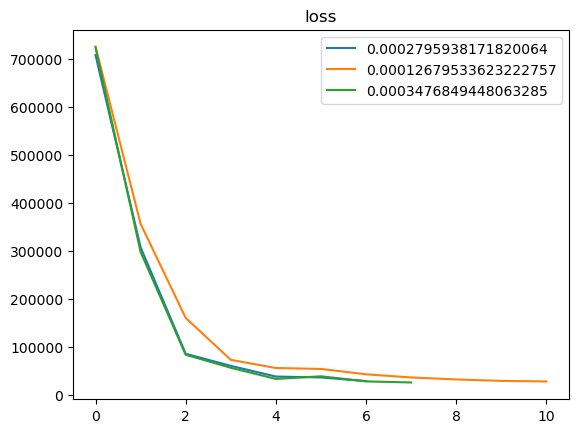

In [27]:

[d.loss.plot(label=d['config/OPTIMIZER/parameters/lr'][0]) for d in dfs.values() if 'loss' in d.columns]
plt.title('loss')
plt.legend()
# dfs['/home/ec2-user/ray_results/train_loop_per_worker_2025-02-10_22-29-19/train_loop_per_worker_78230_00000_0_2025-02-10_22-29-19']
# dfs

In [65]:
# for result in results:
#     display(result.metrics_dataframe.iloc[-1][['config/OPTIMIZER/parameters/lr', 'loss', 'l1', 'l0']])

results_df = pd.DataFrame([result.metrics_dataframe.iloc[-1][['config/OPTIMIZER/parameters/lr', 'n_tokens', 'loss', 'l1', 'l0']] for result in results])
results_df.rename(columns={'config/OPTIMIZER/parameters/lr': 'lr'}, inplace=True)
results_df.sort_values(['loss', 'l0'], inplace=True)
results_df

,lr,n_tokens,loss,l1,l0
122,0.000401,1000000,21639.250000,4740.429688,1930.038208
122,0.000491,1000000,24664.117188,4726.380371,1347.833374
122,0.000207,1000000,25330.941406,4693.235352,4313.798828
122,0.000450,1000000,25462.597656,4461.587402,1556.486084
122,0.000969,1000000,26639.958984,4489.401855,460.312500
122,0.000910,1000000,26678.003906,4342.301758,455.369781
61,0.000963,507904,31442.949219,3585.637695,474.313110
61,0.000156,507904,35988.597656,4773.797363,6555.136719
61,0.000124,507904,37124.464844,5299.757812,7630.242676
61,0.000985,507904,41580.789062,3500.942383,410.660278
